In [48]:
# import 'world_development_data.csv' as dataframe
import pandas as pd
df = pd.read_csv('world_development_data.csv')
df.head()

,Year,Country,Region,SubRegion,SurfAreaSqKm,PopTotal,PopDens,PopGrowth%,GDP,GDPGrowth%,...,GNIAtlas,Imports%GDP,IndValAdd%GDP,InflConsPric%,LifeExpBirth,MerchTrade%GDP,MobileSubs/100,MortRateU5,NetMigr,UrbanPopGrowth%
0,2000.0,Afghanistan,Asia,Southern Asia,652860.0,19542982.0,29.963329,1.443803,1.801248e+10,-5.206288,...,1.778669e+10,41.312634,17.178775,37.611028,55.298000,52.777048,0.000000,129.3,-1007135.0,1.861377
1,2000.0,Malta,Europe,Southern Europe,320.0,390087.0,1219.021875,0.645267,4.323339e+09,19.681791,...,4.273280e+09,128.374581,26.939987,-4.512396,78.348780,135.682159,28.667475,7.6,1799.0,0.952299
2,2000.0,Belgium,Europe,Western Europe,30530.0,10251250.0,338.548547,0.242518,2.367925e+11,3.716679,...,2.654129e+11,69.682740,24.943833,2.014617,77.721951,154.515900,54.840339,5.9,32262.0,0.308431
3,2000.0,Marshall Islands,Oceania,Micronesia,180.0,54224.0,301.244444,0.721838,1.153475e+08,1.354079,...,1.500075e+08,100.812761,12.681072,-0.454689,63.275000,55.484514,0.824358,42.1,-1323.0,1.492787
4,2000.0,Mauritania,Africa,Sub-Saharan Africa,1030700.0,2695003.0,2.614731,2.799182,1.779521e+09,-3.918026,...,1.907497e+09,33.423259,29.951850,6.351587,61.028000,45.461676,0.567717,98.8,-2997.0,2.476860


In [49]:
# keep only data in year 2021 and the following columns only [PopGrowth%, GDPGrowth%, UrbanPopGrowth%]
df_filtered = df.loc[df["Year"] == 2021, ["PopGrowth%", "GDPGrowth%", "UrbanPopGrowth%"]]

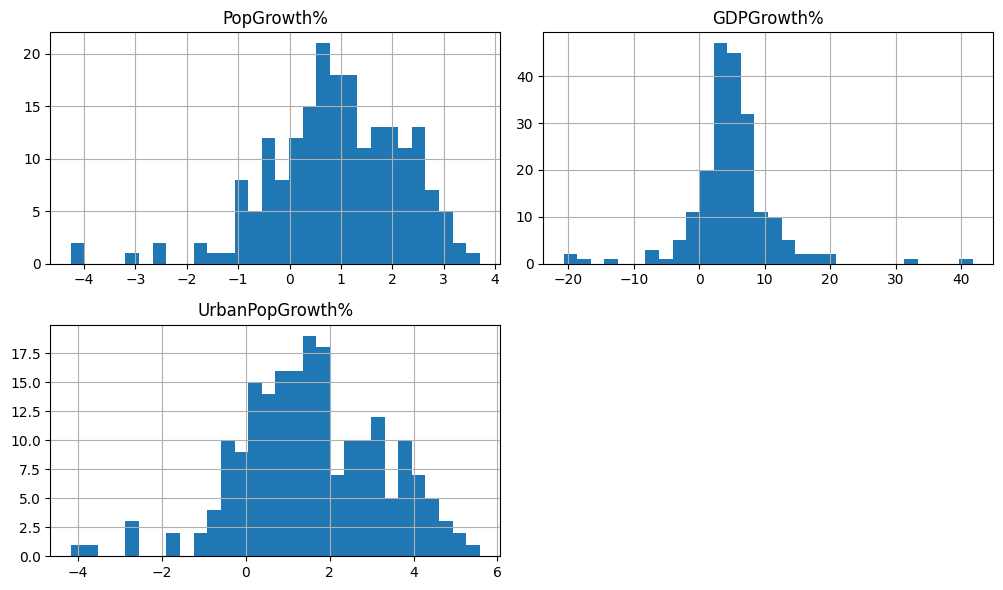

In [50]:
# Plot each column distribution
import matplotlib.pyplot as plt
df_filtered.hist(bins=30, figsize=(10, 6))
plt.tight_layout()
plt.show()

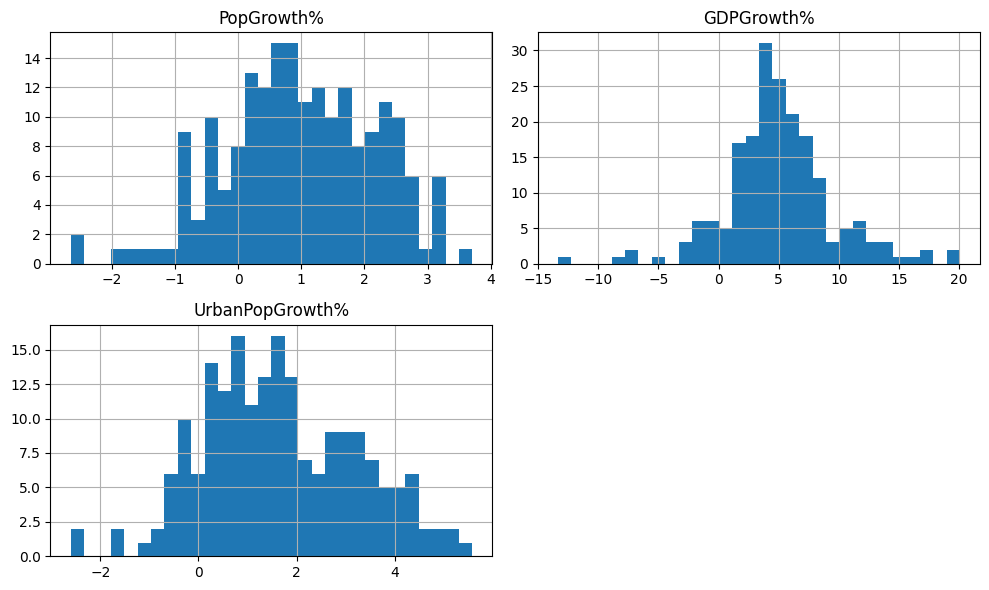

In [51]:
# Exclude outliers
# define outliers to be 3 SD away from the mean
nooutlier = df_filtered[(df_filtered - df_filtered.mean()).abs() <= 3 * df_filtered.std()].dropna()
nooutlier.hist(bins=30, figsize=(10, 6))
plt.tight_layout()
plt.show()

In [ ]:
# Standardize the data
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler
from kneed import KneeLocator
import numpy as np

scaler = StandardScaler()
X = scaler.fit_transform(nooutlier)

# --- Method 1: Elbow Method ---
inertia = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

knee = KneeLocator(range(1, 10), inertia, curve='convex', direction='decreasing')
elbow_k = knee.knee
print(f"Elbow Method → K = {elbow_k}")

# --- Method 2: Silhouette Score ---
sil_scores = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    sil_scores.append(silhouette_score(X, kmeans.labels_))

silhouette_k = np.argmax(sil_scores) + 2
print(f"Silhouette Method → K = {silhouette_k}")

# --- Method 3: Stability (ARI) ---
def stability_score(X, k, runs=10):
    labels_list = []
    for _ in range(runs):
        idx = np.random.choice(len(X), int(0.8 * len(X)), replace=False)
        labels = KMeans(n_clusters=k, n_init=10, random_state=None).fit_predict(X[idx])
        labels_list.append((idx, labels))
    scores = []
    for i in range(len(labels_list)):
        for j in range(i + 1, len(labels_list)):
            idx1, lab1 = labels_list[i]
            idx2, lab2 = labels_list[j]
            common = set(idx1).intersection(idx2)
            if common:
                m1 = {idx1[t]: lab1[t] for t in range(len(idx1))}
                m2 = {idx2[t]: lab2[t] for t in range(len(idx2))}
                scores.append(adjusted_rand_score([m1[c] for c in common], [m2[c] for c in common]))
    return np.mean(scores)

stab_scores = []
for k in range(2, 10):
    stab_scores.append(stability_score(X, k))

stability_k = np.argmax(stab_scores) + 2
print(f"Stability Method → K = {stability_k}")

Elbow Method → K = 3
Silhouette Method → K = 2


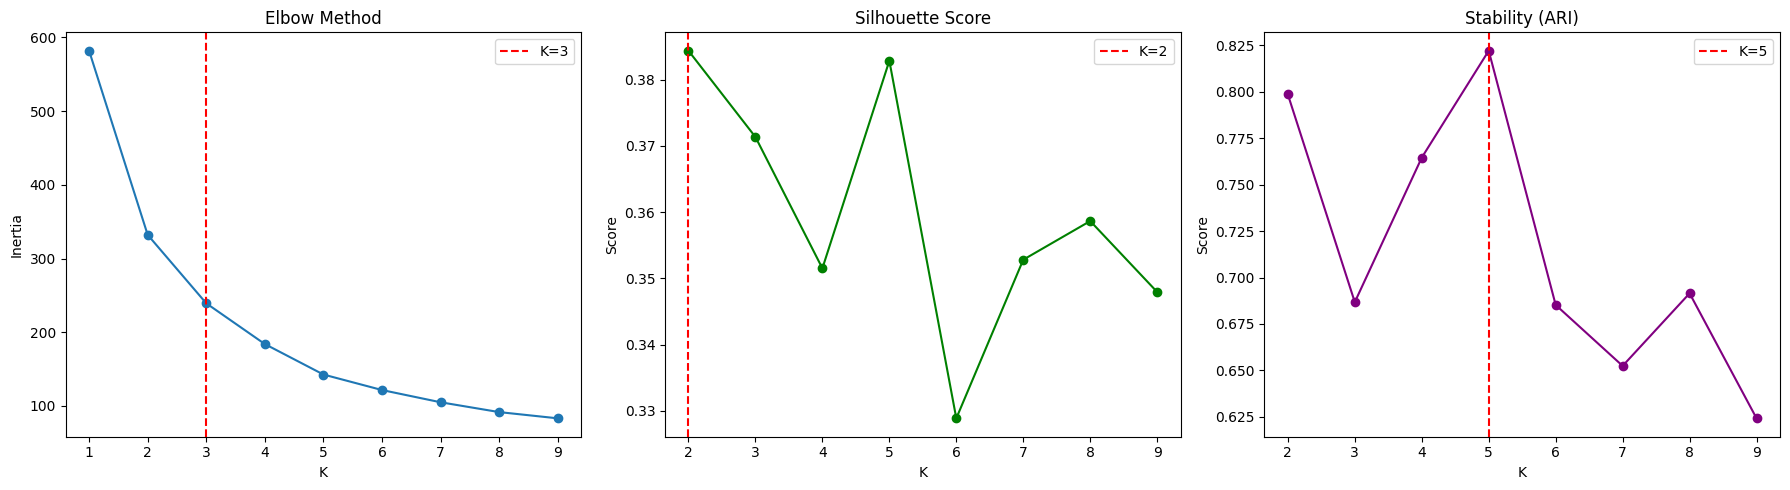


Elbow=3, Silhouette=2, Stability=5
Best K by majority vote: 3


In [ ]:
# Compare all three methods visually
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Elbow
axes[0].plot(range(1, 10), inertia, marker='o')
axes[0].axvline(x=elbow_k, color='r', linestyle='--', label=f'K={elbow_k}')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].legend()

# Silhouette
axes[1].plot(range(2, 10), sil_scores, marker='o', color='green')
axes[1].axvline(x=silhouette_k, color='r', linestyle='--', label=f'K={silhouette_k}')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Score')
axes[1].legend()

# Stability
axes[2].plot(range(2, 10), stab_scores, marker='o', color='purple')
axes[2].axvline(x=stability_k, color='r', linestyle='--', label=f'K={stability_k}')
axes[2].set_title('Stability (ARI)')
axes[2].set_xlabel('K')
axes[2].set_ylabel('Score')
axes[2].legend()

plt.tight_layout()
plt.show()

# Pick the best K by majority vote
from collections import Counter
votes = Counter([elbow_k, silhouette_k, stability_k])
best_k = votes.most_common(1)[0][0]
print(f"\nElbow={elbow_k}, Silhouette={silhouette_k}, Stability={stability_k}")
print(f"Best K by majority vote: {best_k}")

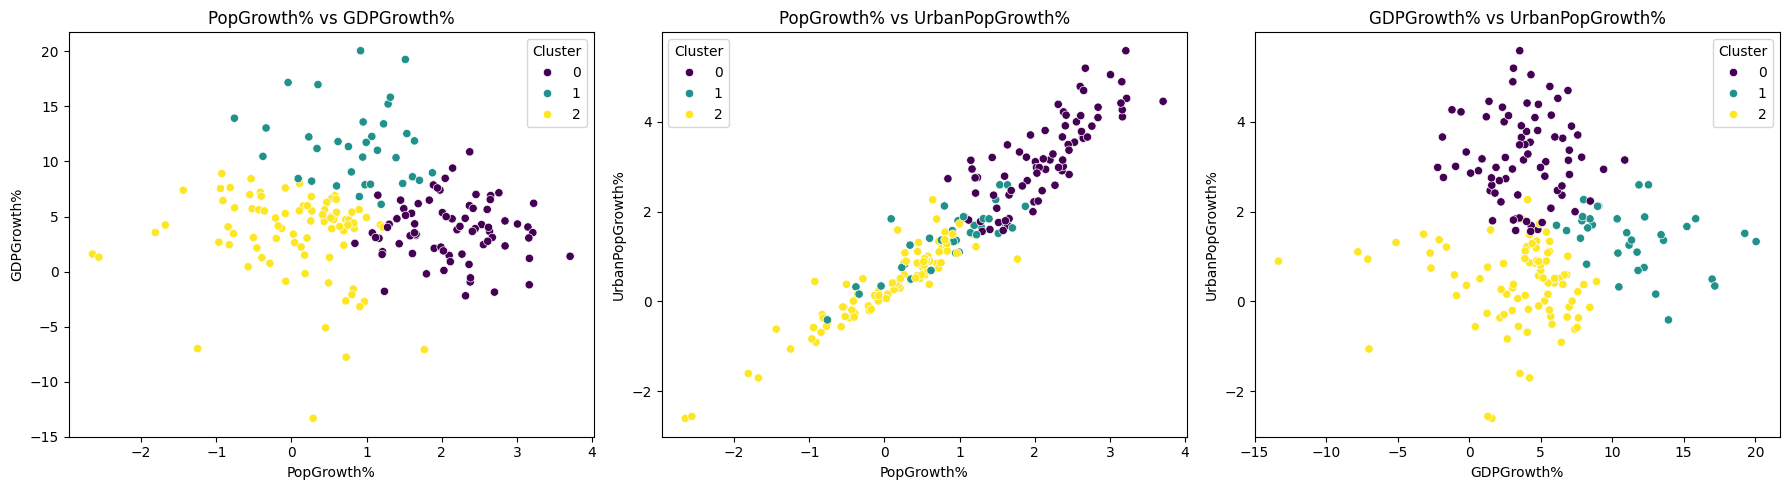

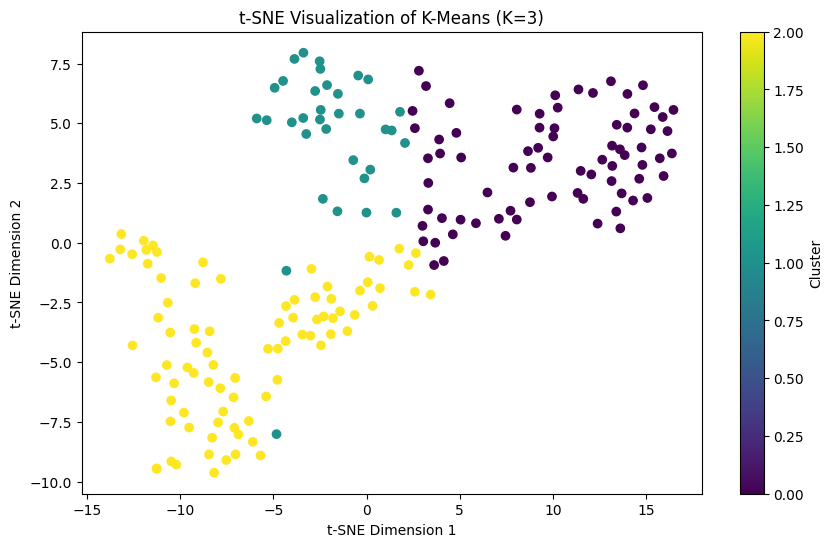

In [ ]:
# Apply K-Means with the best K and plot
import seaborn as sns
from sklearn.manifold import TSNE

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
nooutlier['Cluster'] = kmeans.fit_predict(X)

# Scatter plots across feature pairs
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=nooutlier, x='PopGrowth%', y='GDPGrowth%', hue='Cluster', palette='viridis', ax=axes[0])
axes[0].set_title('PopGrowth% vs GDPGrowth%')

sns.scatterplot(data=nooutlier, x='PopGrowth%', y='UrbanPopGrowth%', hue='Cluster', palette='viridis', ax=axes[1])
axes[1].set_title('PopGrowth% vs UrbanPopGrowth%')

sns.scatterplot(data=nooutlier, x='GDPGrowth%', y='UrbanPopGrowth%', hue='Cluster', palette='viridis', ax=axes[2])
axes[2].set_title('GDPGrowth% vs UrbanPopGrowth%')

plt.tight_layout()
plt.show()

# t-SNE visualization
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(X)

plt.figure(figsize=(10, 6))
plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=nooutlier['Cluster'], cmap='viridis')
plt.colorbar(label='Cluster')
plt.title(f't-SNE Visualization of K-Means (K={best_k})')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()
